# **Análisis Exploratorio de Datos: Titanic**

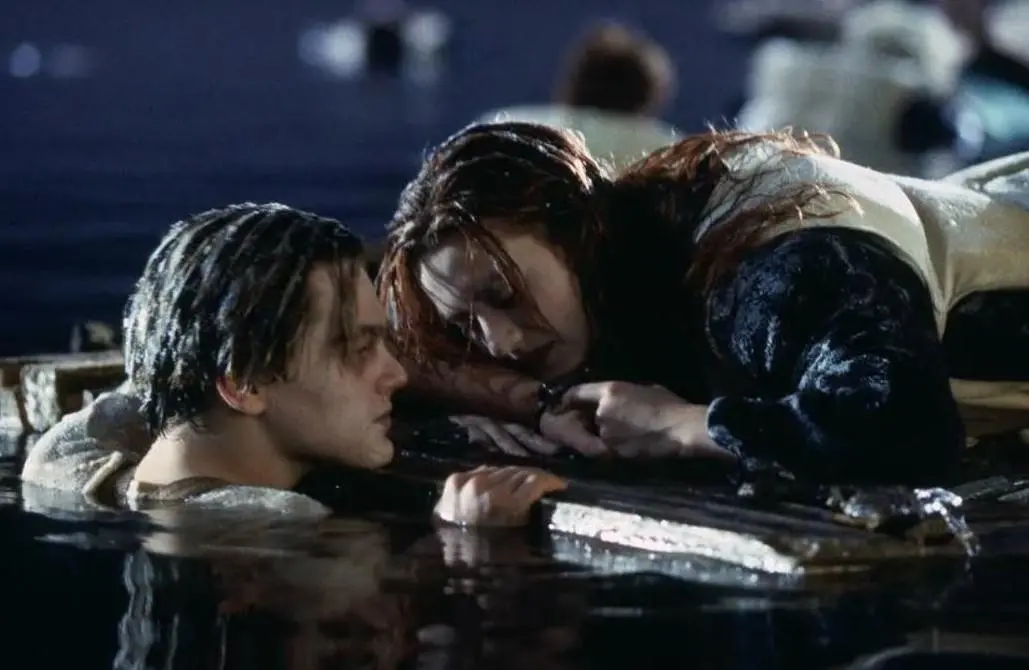

## Pregunta principal

En este notebook realizaremos un Análisis Exploratorio de Datos, también llamado EDA, sobre el dataset Titanic.

La pregunta que queremos responder es:

> ¿Qué factores influyeron en la supervivencia de los pasajeros?

## Objetivo del proyecto

El objetivo de este análisis no es entrenar un modelo de Machine Learning, sino explorar los datos para encontrar patrones y relaciones entre las características de los pasajeros y su supervivencia.

Analizaremos variables como:

- Sexo
- Edad
- Clase del pasajero
- Tarifa pagada
- Puerto de embarque
- Familiares a bordo

A partir de la evidencia que encontremos, construiremos conclusiones claras y justificadas.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuración para que los gráficos se vean mejor
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

# Cargar el archivo Titanic-Dataset.csv
df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))

# Mostrar las primeras filas
display(df.head())

# Mostrar número de filas y columnas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Mostrar información general del dataset
df.info()

# Mostrar nombres de columnas
print(df.columns.tolist())


## 4. Estadística descriptiva
display(df.describe())
display(df.describe(include='object'))
print(df.isnull().sum())


## 4.1. Identificar valores faltantes
print(df.isnull().sum())



Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Filas: 891, Columnas: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 4.2 Revisión de valores faltantes

En esta sección revisamos si el dataset contiene valores faltantes.

Los valores faltantes son datos que no están registrados en algunas columnas. En un EDA es importante detectarlos porque pueden afectar los cálculos, los gráficos y las conclusiones.

Antes de decidir si eliminamos o rellenamos datos, primero vamos a medir cuántos valores faltan en cada columna.

In [49]:
# Cantidad de valores faltantes por columna
missing_values = df.isnull().sum()

# Porcentaje de valores faltantes por columna
missing_percent = (missing_values / len(df)) * 100

# Unimos ambos resultados en una tabla
missing_table = pd.DataFrame({
    "Valores faltantes": missing_values,
    "Porcentaje faltante": missing_percent
})

# Mostramos solo las columnas que tienen valores faltantes
missing_table = missing_table[missing_table["Valores faltantes"] > 0]

display(missing_table)

,Valores faltantes,Porcentaje faltante
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


### Visualización opcional de valores faltantes

Además de revisar la tabla, podemos crear un gráfico sencillo para comparar visualmente qué columnas tienen más valores faltantes.

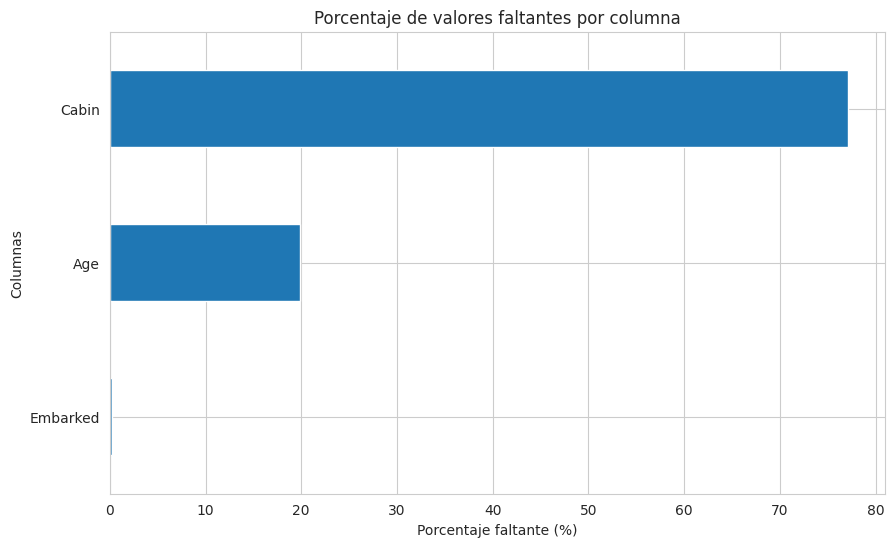

In [50]:
# Gráfico de porcentaje de valores faltantes
missing_table["Porcentaje faltante"].sort_values().plot(kind="barh")

plt.title("Porcentaje de valores faltantes por columna")
plt.xlabel("Porcentaje faltante (%)")
plt.ylabel("Columnas")
plt.show()

## 4.3 Eliminación de columnas irrelevantes

Después de revisar la estructura del dataset y los valores faltantes, podemos eliminar algunas columnas que no aportan directamente al análisis de supervivencia.

En esta primera limpieza eliminaremos:

- `PassengerId`: es solo un identificador de cada pasajero.
- `Name`: contiene nombres únicos, por lo que no aporta directamente como variable categórica simple.
- `Ticket`: contiene códigos de billete difíciles de interpretar en este análisis inicial.
- `Cabin`: tiene muchos valores faltantes, por lo que no la usaremos directamente.

Antes de crear columnas irrelevantes vamos a crear una copia llamada `df_eda`. para trabajar de forma segura, para así conversar el dataset original intacto.

In [51]:

# Creamos una copia del dataset original
df_eda = df.copy()

# Eliminamos columnas que no usaremos en este análisis inicial, axis 1 significa que elimino columnas y si fuese 0 son filas
df_eda = df_eda.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Ver cómo quedó el dataset después de eliminar columnas
print("Dataset después de eliminar columnas:")
display(df_eda.head())

# Ver el nuevo tamaño del dataset
print(f"Filas: {df_eda.shape[0]}, Columnas: {df_eda.shape[1]}")

Dataset después de eliminar columnas:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Filas: 891, Columnas: 8


In [52]:
# Revisamos valores faltantes después de eliminar columnas
print(df_eda.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


## 4.4 Imputación de valores faltantes

Después de revisar los valores faltantes, encontramos que:

- `Age` tiene valores faltantes.
- `Embarked` tiene pocos valores faltantes.

Para no perder muchas filas, vamos a rellenar los valores faltantes.

A este proceso se le llama imputación.

En el caso de `Age`, usaremos la mediana porque es una medida más robusta que el promedio cuando existen valores extremos.

En este caso usaremos la mediana de `Age`. ¿Por qué la mediana?
Porque la edad puede tener valores extremos. Por ejemplo, personas muy mayores o bebés. La mediana suele ser más estable que el promedio cuando hay valores extremos.

In [53]:
# Calculamos la mediana de la edad
median_age = df_eda["Age"].median()

# Rellenamos los valores faltantes de Age con la mediana
df_eda["Age"] = df_eda["Age"].fillna(median_age)

# Mostramos el valor usado para imputar
print(f"Valores de Age imputados con la mediana: {median_age}")

# Verificamos cuántos valores faltantes quedan en Age
print("Valores faltantes en Age:", df_eda["Age"].isnull().sum())

Valores de Age imputados con la mediana: 28.0
Valores faltantes en Age: 0


### Imputación de `Embarked`

La variable `Embarked` indica el puerto de embarque del pasajero.

Como es una variable categórica, es decir, contiene categorías y no números continuos, rellenaremos los valores faltantes usando la moda.

La moda es el valor más frecuente de una columna.

In [54]:
# Calculamos la moda de Embarked
mode_embarked = df_eda["Embarked"].mode()[0]

# Rellenamos los valores faltantes de Embarked con la moda
df_eda["Embarked"] = df_eda["Embarked"].fillna(mode_embarked)

# Mostramos el valor usado para imputar
print(f"Valores de Embarked imputados con la moda: {mode_embarked}")

# Verificamos cuántos valores faltantes quedan en Embarked
print("Valores faltantes en Embarked:", df_eda["Embarked"].isnull().sum())

# Mostramos las primeras 10 filas
display(df_eda.head(10))

Valores de Embarked imputados con la moda: S
Valores faltantes en Embarked: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,28.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


### Verificación después de la imputación

Después de rellenar los valores faltantes de `Age` y `Embarked`, revisamos nuevamente si quedan datos faltantes en el dataset.

Esta verificación es importante para confirmar que la limpieza se aplicó correctamente.

In [55]:
# Verificamos que no queden valores faltantes
print(df_eda.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 4.5 Eliminación de filas con valores faltantes restantes

Después de imputar los valores faltantes de `Age` y `Embarked`, revisamos nuevamente el dataset y encontramos que ya no quedan valores faltantes.

Por este motivo, no fue necesario eliminar filas con `dropna()`.

Esta decisión es importante porque eliminar filas reduce el tamaño del dataset. En este caso, como la imputación resolvió los valores faltantes, conservamos todos los registros.

In [56]:
# Verificación final de valores faltantes
print(df_eda.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## Conclusión de la limpieza inicial

En esta etapa eliminamos columnas que no usaremos en el análisis inicial e imputamos los valores faltantes de las columnas `Age` y `Embarked`.

Como resultado, el dataset quedó sin valores faltantes y listo para continuar con el análisis exploratorio.

In [57]:
# Ver columnas actuales del dataset limpio
print(df_eda.columns.tolist())

# Ver las primeras filas del dataset limpio
display(df_eda.head())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 5. Renombrar columnas

Antes de continuar con el análisis, revisamos los nombres de las columnas.

Algunas columnas tienen nombres abreviados, como `Pclass`, `SibSp` y `Parch`. Para que el notebook sea más claro, renombraremos esas columnas con nombres más descriptivos.

In [58]:
# Renombramos columnas para que sean más fáciles de interpretar
df_eda = df_eda.rename(columns={
    "Pclass": "Passenger_Class",
    "SibSp": "Siblings_Spouses",
    "Parch": "Parents_Children"
})

# Ver los nombres nuevos de las columnas
print("Columnas después de renombrar:")
print(df_eda.columns.tolist())

# Mostrar las primeras filas
display(df_eda.head())

Columnas después de renombrar:
['Survived', 'Passenger_Class', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Fare', 'Embarked']


,Survived,Passenger_Class,Sex,Age,Siblings_Spouses,Parents_Children,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 6. Análisis univariado

El análisis univariado consiste en estudiar una sola variable a la vez.

En esta sección vamos a observar la distribución de cada variable para entender cómo se comporta antes de compararla con otras.

Comenzamos con `Survived`, porque es la variable principal del análisis.

### 6.1 Variable categórica: `Survived`

La variable `Survived` indica si un pasajero sobrevivió o no:

- `0`: No sobrevivió
- `1`: Sobrevivió

Primero contaremos cuántos pasajeros hay en cada grupo.

In [59]:
# Contar cuántos pasajeros sobrevivieron y cuántos no
survival_counts = df_eda["Survived"].value_counts().sort_index()

print(survival_counts)

Survived
0    549
1    342
Name: count, dtype: int64


In [60]:
# Calcular porcentajes de supervivencia
survival_percent = df_eda["Survived"].value_counts(normalize=True).sort_index() * 100

# Crear una tabla resumen
survival_summary = pd.DataFrame({
    "Count": survival_counts,
    "Percentage": survival_percent.round(2)
})

display(survival_summary)

,Count,Percentage
Survived,,
0,549,61.62
1,342,38.38


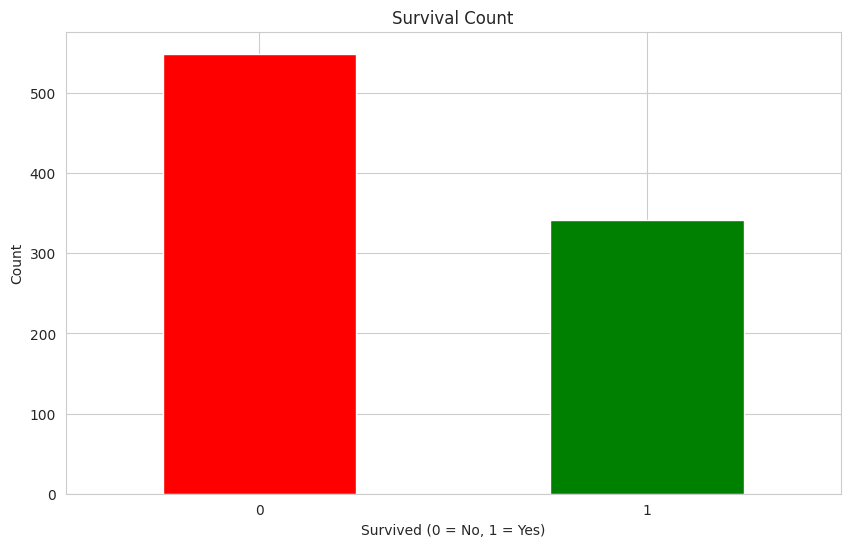

In [61]:
# Gráfico de barras para visualizar la supervivencia
survival_counts.plot(kind="bar", color=["red", "green"])

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Interpretación

En el dataset hay 891 pasajeros registrados.

De ellos:

- 549 no sobrevivieron, lo que representa el 61.62%.
- 342 sobrevivieron, lo que representa el 38.38%.

Esto muestra que la mayoría de los pasajeros del dataset no sobrevivió al naufragio.

A partir de este resultado, el análisis continuará buscando qué características diferencian a los pasajeros que sobrevivieron de los que no sobrevivieron.

### 6.2 Variable categórica: `Sex`

La variable `Sex` indica el sexo del pasajero.

En esta parte analizamos cuántos hombres y mujeres hay en el dataset. Esto nos servirá más adelante para estudiar si el sexo tuvo relación con la supervivencia.

In [62]:
# Contar cuántos hombres y mujeres hay en el dataset
sex_counts = df_eda["Sex"].value_counts()

print(sex_counts)

Sex
male      577
female    314
Name: count, dtype: int64


In [63]:
# Calcular porcentajes por sexo
sex_percent = df_eda["Sex"].value_counts(normalize=True) * 100

# Crear una tabla resumen
sex_summary = pd.DataFrame({
    "Count": sex_counts,
    "Percentage": sex_percent.round(2)
})

display(sex_summary)

,Count,Percentage
Sex,,
male,577,64.76
female,314,35.24


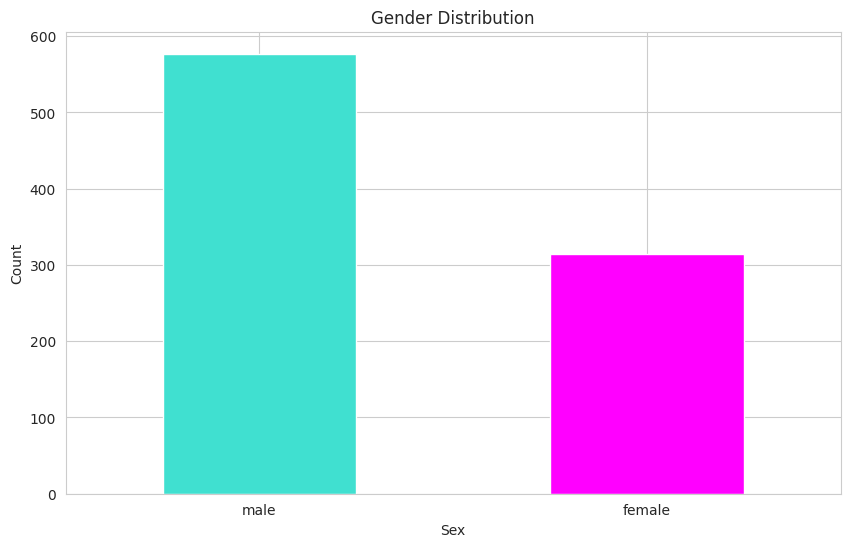

In [64]:
# Gráfico de barras para visualizar la distribución por sexo
sex_counts.plot(kind="bar", color=["turquoise", "magenta"])

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Interpretación

En el dataset hay más hombres que mujeres.

- `male`: 577 pasajeros, que representan el 64.76%.
- `female`: 314 pasajeras, que representan el 35.24%.

Esto muestra que la mayoría de las personas registradas en el dataset eran hombres.

Por ahora solo estamos analizando la distribución de la variable `Sex`. Más adelante compararemos esta variable con `Survived` para estudiar si el sexo influyó en la supervivencia.

### 6.3 Variable numérica: `Age`

La variable `Age` representa la edad de los pasajeros.

Como es una variable numérica, podemos analizar su distribución con un histograma.

Un histograma divide los valores en rangos y muestra cuántos datos caen en cada rango. Esto nos ayuda a ver qué edades eran más comunes en el dataset.

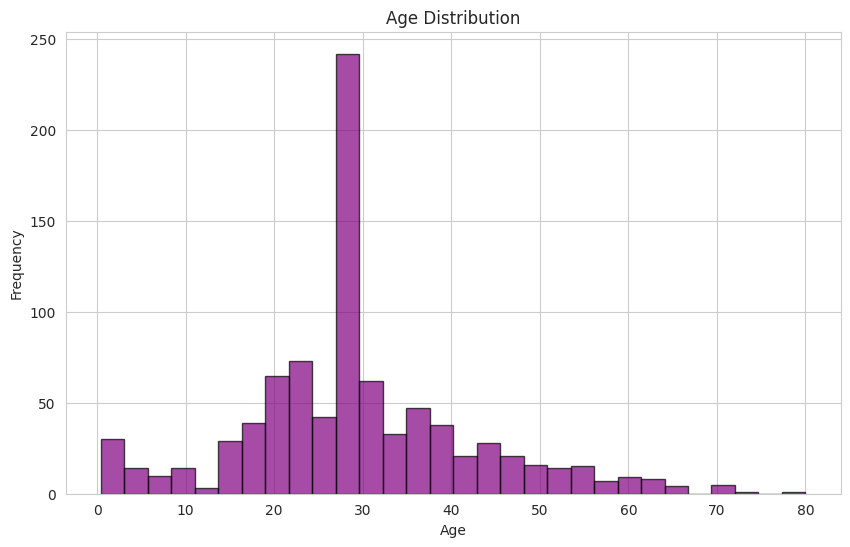

In [65]:
# Histograma para ver la distribución de edades
df_eda["Age"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="purple"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### 6.4 Variable numérica: `Fare`

La variable `Fare` representa la tarifa pagada por el billete.

Para analizarla usaremos un boxplot. Este gráfico permite observar la distribución de una variable numérica y detectar posibles valores extremos, también llamados outliers.

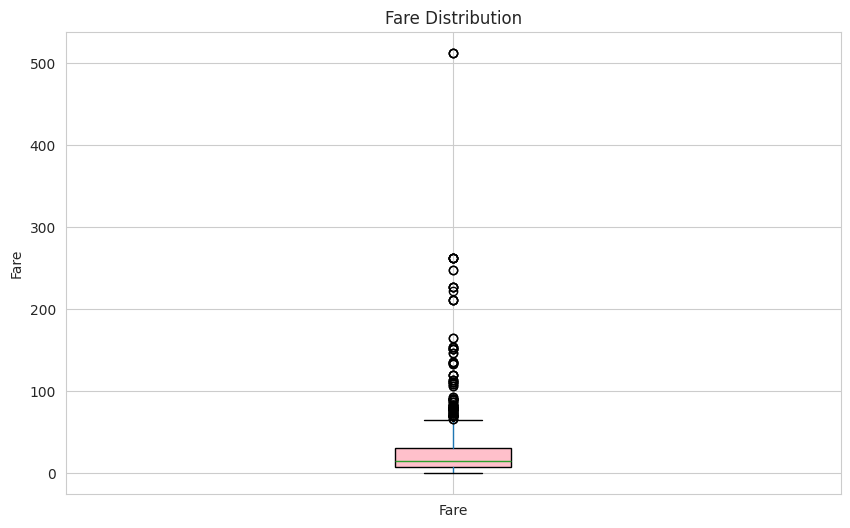

In [66]:
# Boxplot para observar la distribución de Fare y detectar valores extremos
df_eda.boxplot(
    column="Fare",
    patch_artist=True,
    boxprops=dict(facecolor="pink")
)

plt.title("Fare Distribution")
plt.ylabel("Fare")
plt.show()

## 7. Análisis bivariado

El análisis bivariado consiste en estudiar la relación entre dos variables.

En esta etapa empezamos a comparar distintas variables con `Survived`, que es nuestra variable principal. Esto nos ayudará a identificar qué factores pudieron influir en la supervivencia.

### 7.1 Supervivencia según sexo

En esta sección analizamos la relación entre `Sex` y `Survived`.

Queremos responder:

> ¿Hubo diferencias de supervivencia entre hombres y mujeres?

Para ello usaremos una tabla cruzada. Esta tabla nos permite comparar cuántas personas sobrevivieron y cuántas no dentro de cada grupo.

In [67]:
# Tabla cruzada con porcentajes por sexo
survival_by_sex = pd.crosstab(
    df_eda["Sex"],
    df_eda["Survived"],
    normalize="index"
) * 100

print("Porcentaje de supervivencia por sexo:")
display(survival_by_sex.round(2))

Porcentaje de supervivencia por sexo:


Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


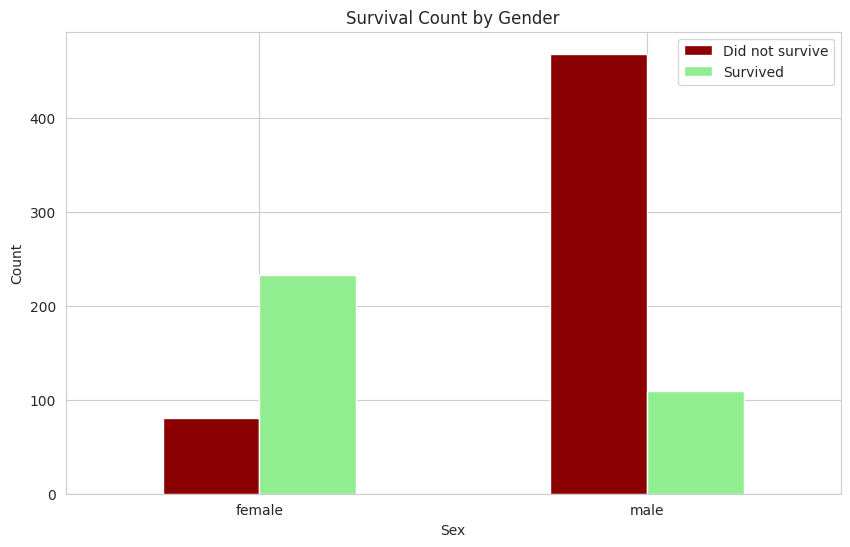

In [68]:
# Gráfico de barras agrupadas para comparar supervivencia por sexo
pd.crosstab(df_eda["Sex"], df_eda["Survived"]).plot(
    kind="bar",
    color=["darkred", "lightgreen"]
)

plt.title("Survival Count by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(["Did not survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

### Interpretación

La tasa de supervivencia fue mucho mayor en mujeres que en hombres.

- El 74.20% de las mujeres sobrevivió.
- El 18.89% de los hombres sobrevivió.

Esto sugiere que el sexo fue un factor importante en la supervivencia. Este resultado es coherente con la idea histórica de priorizar a mujeres y niños durante la evacuación.

### 7.2 Supervivencia según clase del pasajero

En esta sección analizamos la relación entre `Passenger_Class` y `Survived`.

La variable `Passenger_Class` indica la clase del billete:

- `1`: First class
- `2`: Second class
- `3`: Third class

Queremos observar si la clase en la que viajaba una persona estuvo relacionada con sus probabilidades de sobrevivir.

In [69]:
# Tabla cruzada con porcentajes de supervivencia por clase
survival_by_class = pd.crosstab(
    df_eda["Passenger_Class"],
    df_eda["Survived"],
    normalize="index"
) * 100

print("Porcentaje de supervivencia por clase:")
display(survival_by_class.round(2))

Porcentaje de supervivencia por clase:


Survived,0,1
Passenger_Class,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


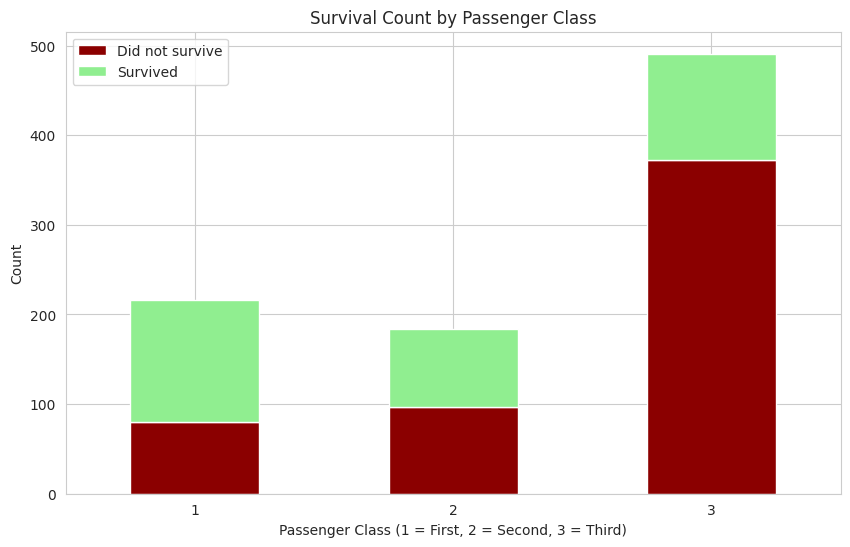

In [70]:
# Gráfico de barras apiladas para comparar supervivencia por clase -stacked true hace que se apile
pd.crosstab(df_eda["Passenger_Class"], df_eda["Survived"]).plot(
    kind="bar",
    stacked=True,
    color=["darkred", "lightgreen"]
)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class (1 = First, 2 = Second, 3 = Third)")
plt.ylabel("Count")
plt.legend(["Did not survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

### Interpretación

La supervivencia varía claramente según la clase del pasajero.

- En primera clase sobrevivió el 62.96%.
- En segunda clase sobrevivió el 47.28%.
- En tercera clase sobrevivió el 24.24%.

Esto sugiere que la clase del pasajero estuvo relacionada con la supervivencia. Los pasajeros de primera clase tuvieron una tasa de supervivencia mucho más alta que los de tercera clase.

### 7.3 Edad según supervivencia

En esta sección comparamos la distribución de edad entre quienes sobrevivieron y quienes no sobrevivieron.

Esto nos ayuda a observar si ciertos grupos de edad, como niños, adultos o personas mayores, parecen haber tenido diferencias en la supervivencia.

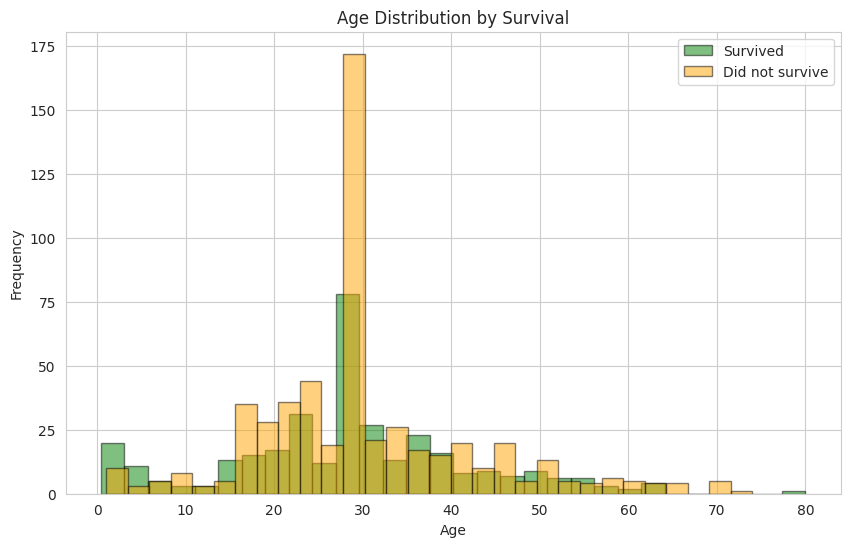

In [71]:
# Distribución de edades de quienes sobrevivieron
df_eda[df_eda["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=30,
    alpha=0.5,
    label="Survived",
    color="green",
    edgecolor="black"
)

# Distribución de edades de quienes no sobrevivieron
df_eda[df_eda["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=30,
    alpha=0.5,
    label="Did not survive",
    color="orange",
    edgecolor="black"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 7.4 Tarifa según supervivencia

En esta sección comparamos la variable `Fare` con `Survived`.

Queremos observar si los pasajeros que pagaron tarifas más altas presentan una distribución diferente en la supervivencia.

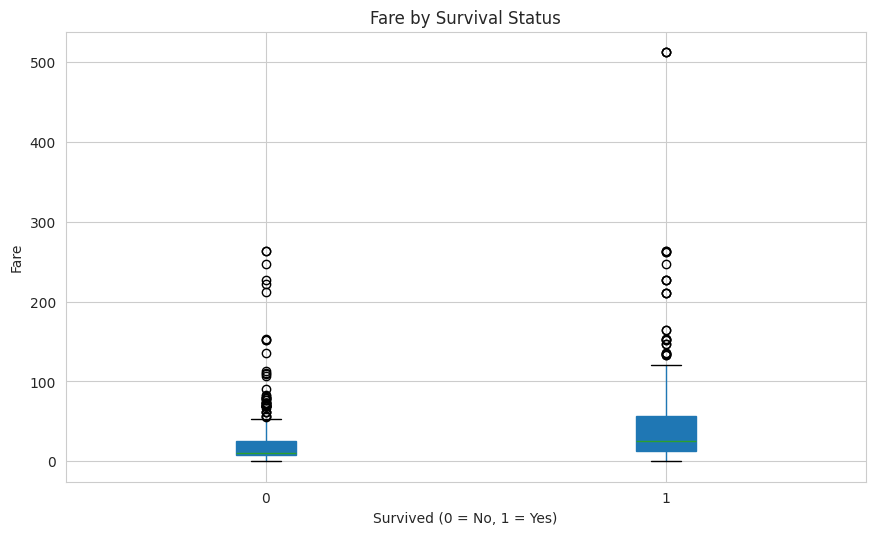

In [72]:
# Boxplot comparativo de Fare según supervivencia
df_eda.boxplot(
    column="Fare",
    by="Survived",
    patch_artist=True
)

plt.title("Fare by Survival Status")
plt.suptitle("")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

In [73]:
# Mediana de Fare según supervivencia
fare_median_by_survival = df_eda.groupby("Survived")["Fare"].median()

display(fare_median_by_survival)



,Fare
Survived,
0,10.5
1,26.0


In [74]:
# Promedio de Fare según supervivencia
fare_mean_by_survival = df_eda.groupby("Survived")["Fare"].mean()

display(fare_mean_by_survival)

,Fare
Survived,
0,22.117887
1,48.395408


### Interpretación

El boxplot muestra que los pasajeros que sobrevivieron tienden a tener tarifas más altas que los que no sobrevivieron.

La mediana de `Fare` parece mayor en el grupo `Survived = 1`. Esto sugiere una posible relación entre pagar una tarifa más alta y tener mayor probabilidad de supervivencia.

Sin embargo, esta relación puede estar conectada con la clase del pasajero, ya que las tarifas más altas suelen corresponder a pasajeros de primera clase.


*Cómo leer cada caja:*



*   La línea dentro de la caja es la mediana.
*   La caja muestra la zona donde está el 50% central de los datos.
*   Las líneas que salen de la caja muestran el rango típico.
*   Los puntos sueltos son valores extremos, es decir, tarifas mucho más altas que la mayoría.




## 8. Análisis multivariado

El análisis multivariado consiste en analizar varias variables al mismo tiempo.

En esta sección comenzaremos con una matriz de correlación, que nos permite observar la relación entre variables numéricas del dataset.

La correlación toma valores entre -1 y 1:

- Valores cercanos a 1 indican relación positiva.
- Valores cercanos a -1 indican relación negativa.
- Valores cercanos a 0 indican poca o ninguna relación lineal.

Es importante recordar que correlación no significa causalidad.

### 8.1 Matriz de correlación

Para calcular correlaciones usamos solo variables numéricas.

Esto es necesario porque variables de texto como `Sex` o `Embarked` no pueden incluirse directamente en una matriz de correlación.

In [75]:
# Seleccionar solo columnas numéricas
numeric_df = df_eda.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
correlation = numeric_df.corr()

print("Matriz de correlación entre variables numéricas:")
display(correlation.round(2))

Matriz de correlación entre variables numéricas:


,Survived,Passenger_Class,Age,Siblings_Spouses,Parents_Children,Fare
Survived,1.00,-0.34,-0.06,-0.04,0.08,0.26
Passenger_Class,-0.34,1.00,-0.34,0.08,0.02,-0.55
Age,-0.06,-0.34,1.00,-0.23,-0.17,0.10
Siblings_Spouses,-0.04,0.08,-0.23,1.00,0.41,0.16
Parents_Children,0.08,0.02,-0.17,0.41,1.00,0.22
Fare,0.26,-0.55,0.10,0.16,0.22,1.00


### 8.2 Heatmap de correlación

Un heatmap, o mapa de calor, representa los valores de una tabla usando colores.

En este caso, usaremos el heatmap para visualizar la matriz de correlación entre variables numéricas.

Los colores ayudan a identificar rápidamente relaciones positivas, negativas o cercanas a cero.

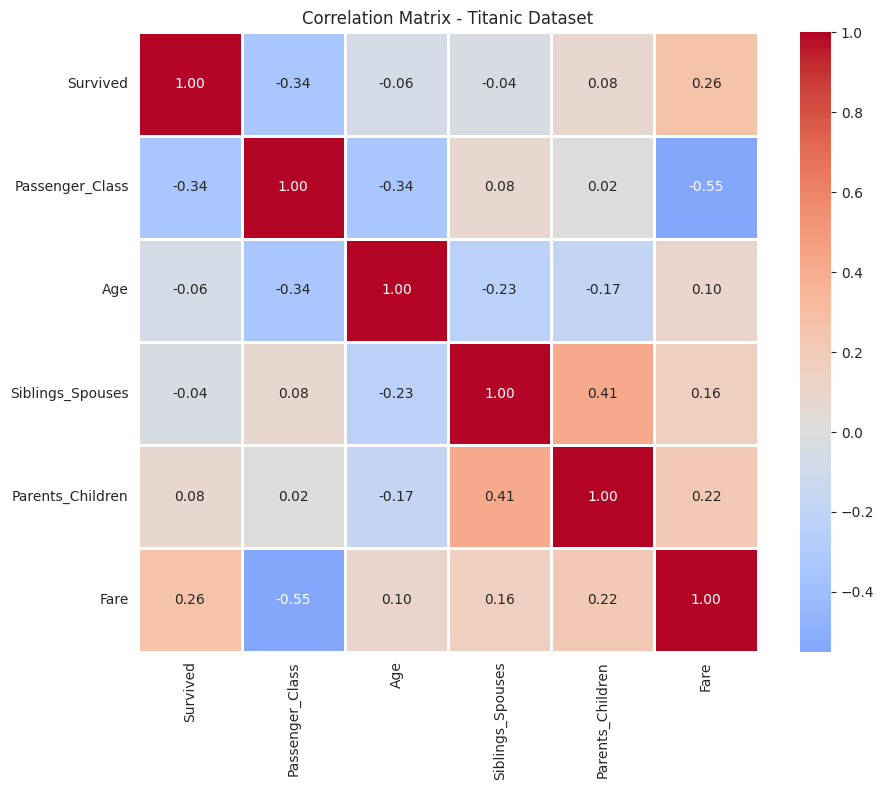

In [76]:
# Crear un heatmap para visualizar las correlaciones
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=1,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix - Titanic Dataset")
plt.tight_layout()
plt.show()

### Interpretación

En el heatmap, la relación más destacada con `Survived` es `Passenger_Class`, con una correlación aproximada de -0.34.

Esta correlación es negativa porque la variable está codificada como:

- `1`: First class
- `2`: Second class
- `3`: Third class

Por lo tanto, a medida que aumenta el número de clase, disminuye la supervivencia. Esto coincide con el análisis anterior, donde observamos que los pasajeros de primera clase tuvieron una tasa de supervivencia mayor que los de tercera clase.

Variables como `Age` y `Siblings_Spouses` muestran correlaciones cercanas a cero, por lo que no presentan una relación lineal fuerte con la supervivencia en esta matriz.

### 8.3 Pairplot

Un pairplot muestra varias relaciones entre variables numéricas al mismo tiempo.

En la diagonal aparecen histogramas de cada variable individual.

Fuera de la diagonal aparecen gráficos de dispersión, donde se comparan dos variables numéricas.

Usaremos `Survived` como color para ver si los pasajeros que sobrevivieron y los que no sobrevivieron forman patrones diferentes.

<function matplotlib.pyplot.show(close=None, block=None)>

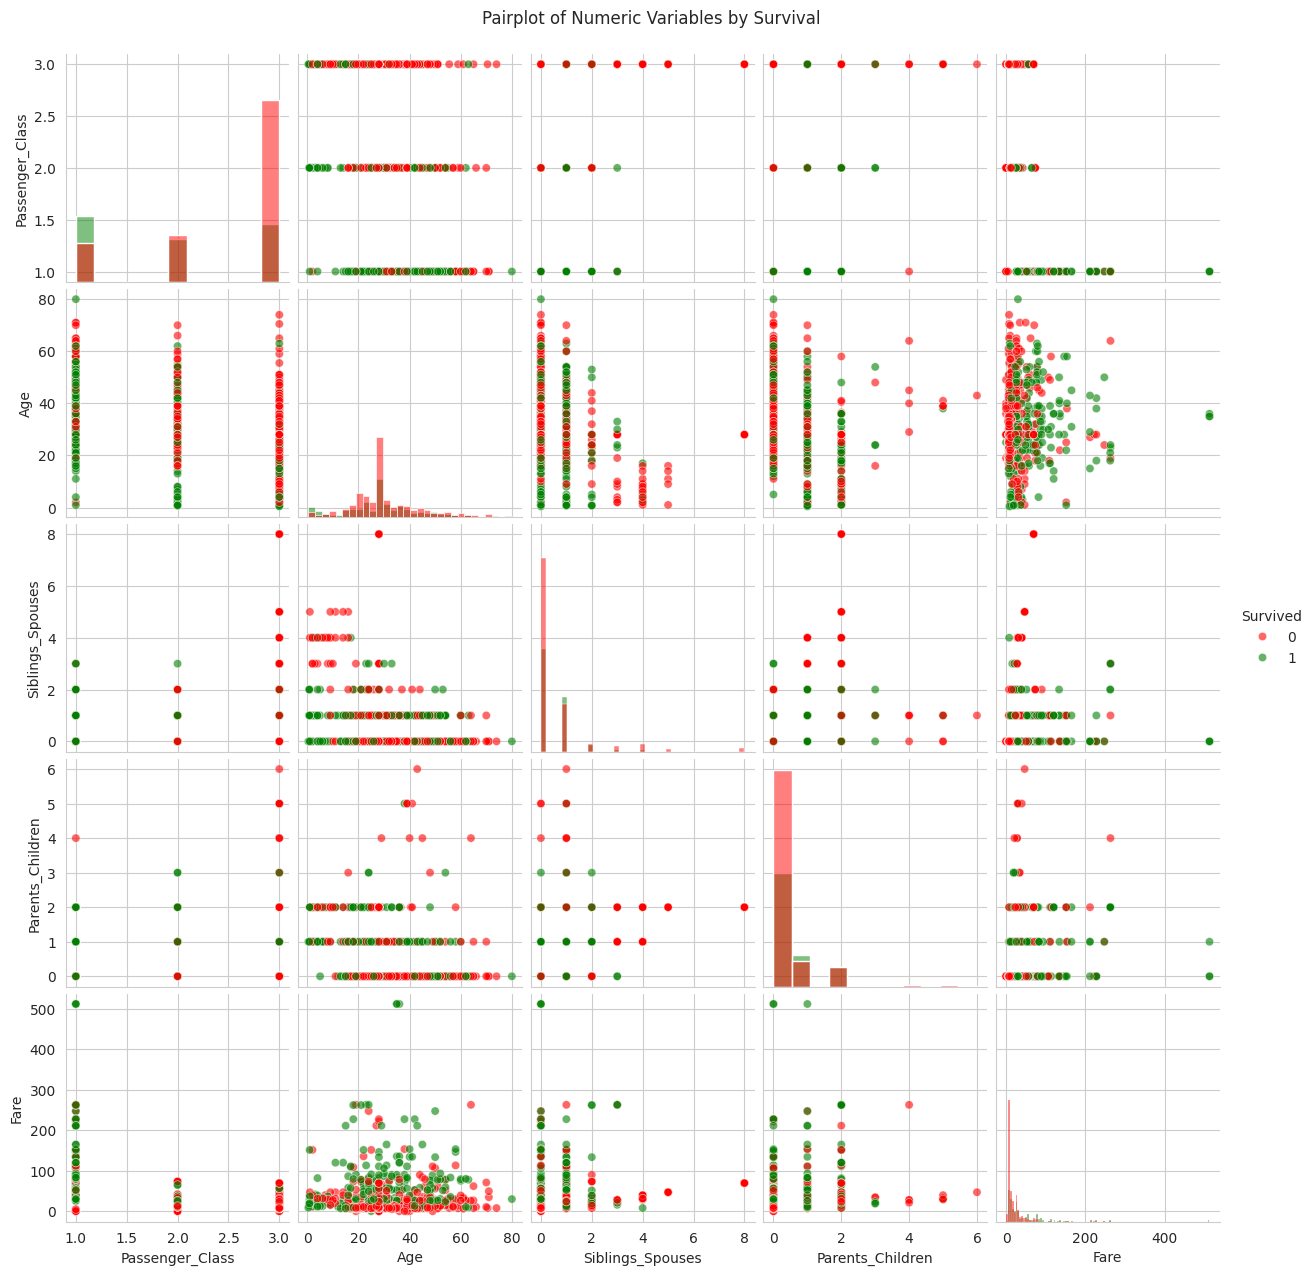

In [77]:
# Pairplot de variables numéricas coloreado por supervivencia

sns.pairplot(
    numeric_df,
    hue="Survived",
    palette={0: "red", 1: "green"},
    diag_kind="hist",
    plot_kws={"alpha" : 0.6}
)

plt.suptitle("Pairplot of Numeric Variables by Survival", y=1.02)
plt.show

### Interpretación

El pairplot permite observar relaciones generales entre variables numéricas según la supervivencia.

En algunos gráficos se observa que los puntos verdes, correspondientes a pasajeros que sobrevivieron, tienden a aparecer con mayor frecuencia en tarifas más altas y clases más altas.

Sin embargo, en variables como `Age`, los puntos de sobrevivientes y no sobrevivientes aparecen bastante mezclados, por lo que no se observa una separación clara solo con esta variable.

Este gráfico confirma visualmente algunos patrones detectados antes, especialmente la relación entre clase, tarifa y supervivencia.

## 9. Feature Engineering básico

Feature engineering significa crear nuevas variables a partir de las variables existentes.

El objetivo es generar información adicional que pueda ayudar a entender mejor los datos.

En este proyecto no usaremos Machine Learning, pero el feature engineering también es útil en EDA porque permite descubrir patrones que no son tan evidentes con las variables originales.

### 9.1 Crear variable `Family_Size`

La variable `Family_Size` representa el tamaño del grupo familiar de cada pasajero dentro del barco.

La crearemos sumando:

- `Siblings_Spouses`: hermanos/as o cónyuge a bordo.
- `Parents_Children`: padres/madres o hijos/as a bordo.
- `1`: el propio pasajero.

Si una persona viajaba sola, su `Family_Size` será 1.

In [78]:
# Crear la variable Family_Size
df_eda["Family_Size"] = (
    df_eda["Siblings_Spouses"] +
    df_eda["Parents_Children"] +
    1
)

print("Nueva columna Family_Size creada: ")

#Ver las columnas relacionadas con el tamaño familiar
display(df_eda[["Siblings_Spouses", "Parents_Children", "Family_Size"]].head(10))


Nueva columna Family_Size creada: 


,Siblings_Spouses,Parents_Children,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


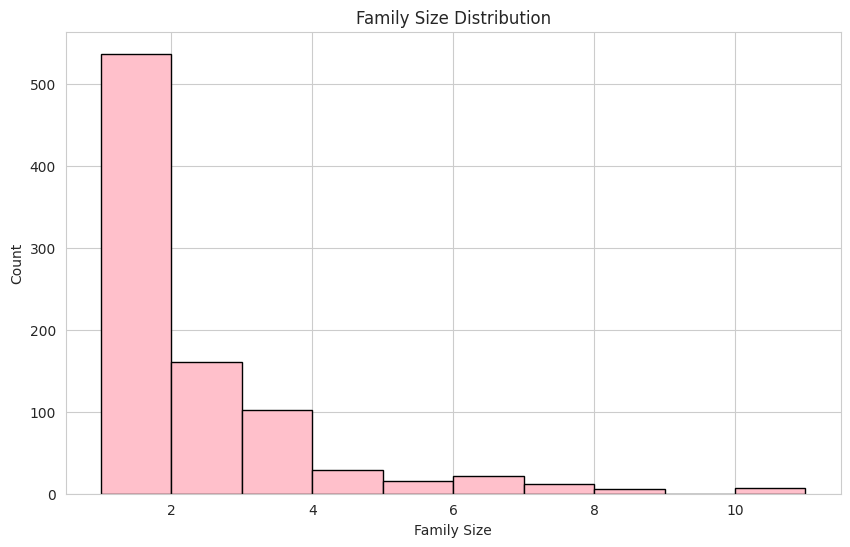

In [79]:
# Visualizar la distribución del tamaño de familia

df_eda["Family_Size"].plot(
    kind="hist",
    bins=10,
    edgecolor="black",
    color="pink"
)

plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

### Interpretación

La mayoría de los pasajeros viajaba sola, es decir, con `Family_Size = 1`.

También se observan pasajeros que viajaban en grupos pequeños, especialmente de 2 o 3 personas.

Los grupos familiares grandes son mucho menos frecuentes, aunque existen algunos casos con tamaños familiares mayores a 10 integrantes.

Esta variable puede ser útil para analizar si viajar solo o acompañado influyó en la supervivencia.

### 9.2 Crear variable `Is_Alone`

A partir de `Family_Size`, crearemos una nueva variable llamada `Is_Alone`.

Esta variable indica si un pasajero viajaba solo o acompañado:

- `1`: viajaba solo.
- `0`: viajaba con familia.

Esto nos permitirá analizar si viajar solo estuvo relacionado con la supervivencia.

In [80]:
# Crear variable binaria: 1 si viaja solo, 0 si viaja con familia
df_eda["Is_Alone"] = (df_eda["Family_Size"] == 1).astype(int)

print("Nueva columna Is_Alone creada:")

# Ver la nueva columna
display(df_eda[["Family_Size", "Is_Alone"]].head(10))

Nueva columna Is_Alone creada:


,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [81]:
# Porcentaje de supervivencia según si viajaban solos o acompañados
survival_by_alone = pd.crosstab(
    df_eda["Is_Alone"],
    df_eda["Survived"],
    normalize="index"
) * 100

print("Porcentaje de supervivencia según si viajaban solos o acompañados:")
display(survival_by_alone.round(2))


Porcentaje de supervivencia según si viajaban solos o acompañados:


Survived,0,1
Is_Alone,,
0,49.44,50.56
1,69.65,30.35


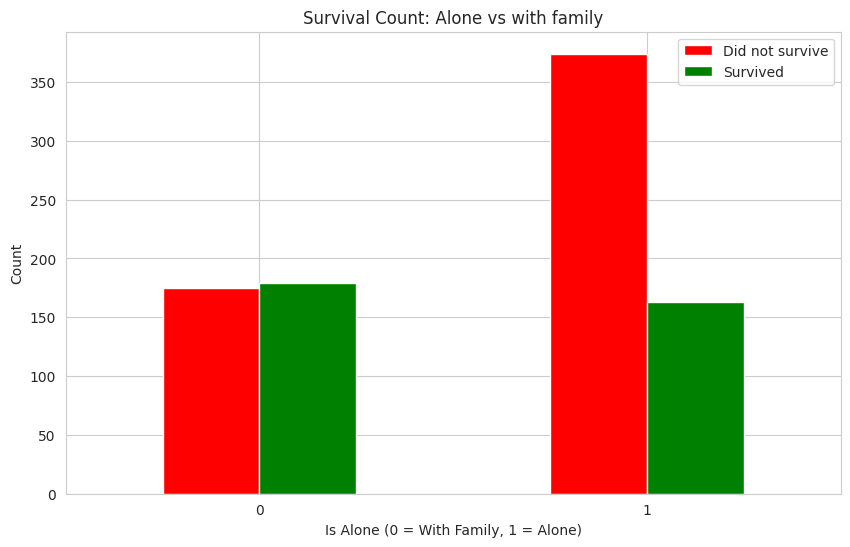

In [82]:
# Gráfico de supervivencia según si viajaban solos o acompañados

pd.crosstab(df_eda["Is_Alone"], df_eda["Survived"]).plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Survival Count: Alone vs with family")
plt.xlabel("Is Alone (0 = With Family, 1 = Alone)")
plt.ylabel("Count")
plt.legend(["Did not survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

Survived,Did not survive,Survived
Is_Alone,,
With Family,49.44,50.56
Alone,69.65,30.35


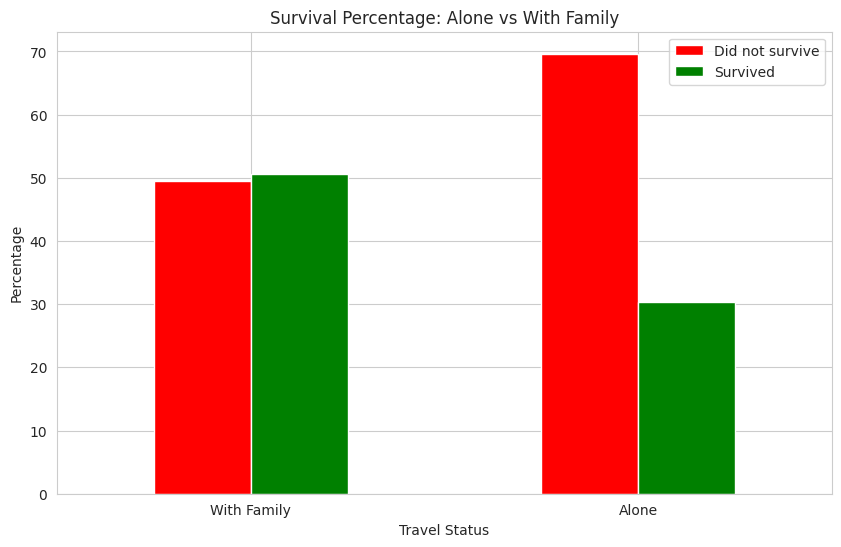

In [83]:
# Crear una tabla más fácil de leer
alone_survival_table = pd.crosstab(
    df_eda["Is_Alone"],
    df_eda["Survived"],
    normalize="index"
) * 100

alone_survival_table = alone_survival_table.rename(
    index={0: "With Family", 1: "Alone"},
    columns={0: "Did not survive", 1: "Survived"}
)

display(alone_survival_table.round(2))


# Tabla de porcentajes por grupo
alone_survival_percent = pd.crosstab(
    df_eda["Is_Alone"],
    df_eda["Survived"],
    normalize="index"
) * 100

# Renombrar para que sea más fácil de leer
alone_survival_percent = alone_survival_percent.rename(
    index={0: "With Family", 1: "Alone"},
    columns={0: "Did not survive", 1: "Survived"}
)

# Gráfico de porcentajes
alone_survival_percent.plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Survival Percentage: Alone vs With Family")
plt.xlabel("Travel Status")
plt.ylabel("Percentage")
plt.legend(["Did not survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

### Interpretación

Los pasajeros que viajaban acompañados tuvieron una tasa de supervivencia mayor que quienes viajaban solos.

Esto sugiere que viajar solo pudo estar asociado con una menor probabilidad de supervivencia. Sin embargo, esta relación debe interpretarse con cuidado, porque también puede estar conectada con otras variables como sexo, edad o clase del pasajero.

### 9.3 Crear variable `Age_Group`

La variable `Age` es numérica y puede tomar muchos valores diferentes.

Para facilitar el análisis, crearemos una nueva variable llamada `Age_Group`, que agrupa las edades en categorías:

- `Child`: 0 a 12 años.
- `Teenager`: 13 a 18 años.
- `Young Adult`: 19 a 35 años.
- `Adult`: 36 a 60 años.
- `Senior`: más de 60 años.

Esto nos ayudará a analizar si ciertos grupos de edad tuvieron diferencias en la supervivencia.

Esta variable convierte una edad numérica en una categoría. Eso suele hacer más fácil interpretar patrones.

In [84]:
# Categorizar edades en grupos significativos
df_eda["Age_Group"] = pd.cut(
    df_eda["Age"],
    bins = [0,12,18,35,60,100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

print("Nueva columna Age_Group creada:")

# Ver la nueva columna
display(df_eda[["Age", "Age_Group"]].head(15))

Nueva columna Age_Group creada:


,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


In [85]:
# Porcentaje de supervivencia por grupo de edad

survival_by_age_group = pd.crosstab(
    df_eda["Age_Group"],
    df_eda["Survived"],
    normalize="index"
) * 100

display(survival_by_age_group.round(2))

Survived,0,1
Age_Group,,
Child,42.03,57.97
Teenager,57.14,42.86
Young Adult,64.67,35.33
Adult,60.00,40.00
Senior,77.27,22.73


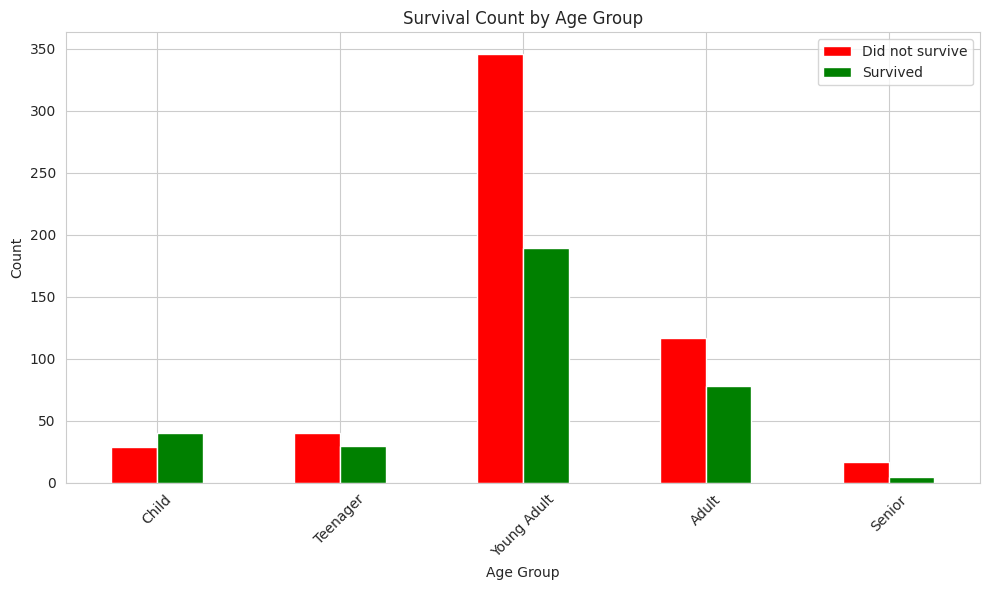

In [86]:
# Gráfico de supervivencia por grupo de edad
pd.crosstab(df_eda["Age_Group"], df_eda["Survived"]).plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Survival Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Did not survive", "Survived"])
plt.tight_layout()
plt.show()

### Interpretación

Al comparar la supervivencia por grupos de edad, se observa que el grupo `Child` es el único donde sobrevivieron más pasajeros de los que fallecieron.

Esto sugiere que los niños pudieron haber tenido prioridad durante la evacuación.

También se observa una alta cantidad de fallecimientos en el grupo `Young Adult`. Sin embargo, esto debe interpretarse con cuidado, ya que este grupo también concentra una gran parte de los pasajeros del dataset.

Por eso, para comparar correctamente los grupos, es más útil revisar los porcentajes de supervivencia dentro de cada grupo y no solo los conteos absolutos.

## 10. Conclusiones

En esta sección resumimos los principales hallazgos del análisis.

Las conclusiones deben estar basadas en los resultados observados durante el EDA, no en suposiciones.

In [87]:
print("=== CONCLUSIONES DEL ANÁLISIS ===\n")

# 1. Tasa de supervivencia general
survival_rate = df_eda["Survived"].mean() * 100
print(f"1. Tasa de supervivencia general: {survival_rate:.2f}%\n")

# 2. Supervivencia por sexo
survival_by_sex = df_eda.groupby("Sex")["Survived"].mean() * 100
print("2. Tasa de supervivencia por sexo:")
print(survival_by_sex.round(2))
print()

# 3. Supervivencia por clase
survival_by_class = df_eda.groupby("Passenger_Class")["Survived"].mean() * 100
print("3. Tasa de supervivencia por clase:")
print(survival_by_class.round(2))
print()

# 4. Edad promedio de sobrevivientes vs no sobrevivientes
avg_age = df_eda.groupby("Survived")["Age"].mean()
print("4. Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")
print()

# 5. Supervivencia según si viajaban solos o acompañados
survival_by_alone = df_eda.groupby("Is_Alone")["Survived"].mean() * 100
print("5. Tasa de supervivencia según si viajaban solos:")
print(survival_by_alone.round(2))

=== CONCLUSIONES DEL ANÁLISIS ===

1. Tasa de supervivencia general: 38.38%

2. Tasa de supervivencia por sexo:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

3. Tasa de supervivencia por clase:
Passenger_Class
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

4. Edad promedio:
   No sobrevivientes: 30.03 años
   Sobrevivientes: 28.29 años

5. Tasa de supervivencia según si viajaban solos:
Is_Alone
0    50.56
1    30.35
Name: Survived, dtype: float64


### Hallazgos principales

La tasa de supervivencia general fue del 38.38%, por lo que la mayoría de los pasajeros registrados no sobrevivió.

El sexo fue uno de los factores más importantes. Las mujeres tuvieron una tasa de supervivencia mucho mayor que los hombres: 74.20% frente a 18.89%.

La clase del pasajero también mostró una relación clara con la supervivencia. Los pasajeros de primera clase tuvieron una tasa de supervivencia del 62.96%, mientras que en tercera clase fue del 24.24%.

En relación con la edad, el grupo de niños fue el único donde sobrevivieron más pasajeros de los que fallecieron. Esto apoya la idea de que los niños pudieron haber tenido prioridad durante la evacuación.

La variable `Fare` mostró que los pasajeros que sobrevivieron tendían a haber pagado tarifas más altas. Sin embargo, esta relación probablemente está conectada con la clase del pasajero.

Finalmente, el análisis de `Is_Alone` sugiere que viajar solo o acompañado también pudo estar relacionado con la supervivencia, aunque esta variable debe interpretarse junto con otras como sexo, edad y clase.

### Respuesta a la pregunta principal

Los factores que más parecen haber influido en la supervivencia fueron:

1. `Sex`: las mujeres sobrevivieron en una proporción mucho mayor que los hombres.
2. `Passenger_Class`: los pasajeros de primera clase tuvieron más probabilidad de sobrevivir que los de tercera clase.
3. `Age_Group`: los niños mostraron una supervivencia relativamente alta.
4. `Fare`: las tarifas más altas se asociaron con mayor supervivencia, posiblemente por su relación con primera clase.
5. `Family_Size` e `Is_Alone`: viajar solo o acompañado mostró diferencias, aunque debe interpretarse con cautela.

En conclusión, la supervivencia en el Titanic no fue aleatoria. Estuvo relacionada principalmente con el sexo, la clase social, la edad y algunas características familiares del pasajero.